### Problem Statement: here is a need for a data-driven approach to predict whether a loan application should be approved based on historical applicant information.

### Develop a Decision Tree classification model using the CART (Classification and Regression Trees) algorithm to predict the Loan_Approved status of applicants.

### Import Libraries and load dataset

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
from sklearn.model_selection import GridSearchCV

In [62]:
df=pd.read_csv(r"Loan.csv")
df.head()

,Age,Annual_Income,Years_Experience,Family_Size,Education,Mortgage,Credit_Score,Credit_Card_Spending,Online_Banking,Fixed_Deposit,City_Tier,Loan_Approved
0,59,171867,34,3,Postgraduate,6263,714,39194,Yes,Yes,Tier-1,Yes
1,22,84735,0,2,Graduate,406999,776,85104,Yes,No,Tier-2,No
2,48,27747,21,3,Graduate,147065,806,43606,Yes,Yes,Tier-3,Yes
3,29,179969,4,2,Postgraduate,192666,763,82077,Yes,Yes,Tier-2,Yes
4,24,196829,0,2,Postgraduate,238615,714,93387,Yes,Yes,Tier-1,Yes


### Understand the dataset

In [63]:
df.shape

(1500, 12)

In [64]:
df.describe()

,Age,Annual_Income,Years_Experience,Family_Size,Mortgage,Credit_Score,Credit_Card_Spending
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,40.358667,137519.260000,16.571333,2.992667,160796.028000,681.097333,49892.488667
std,11.407868,65808.848137,11.169426,1.409706,110149.628944,101.443175,28148.973310
min,21.000000,25050.000000,0.000000,1.000000,0.000000,500.000000,2005.000000
25%,31.000000,80318.750000,7.000000,2.000000,72536.250000,594.000000,25706.000000
50%,40.000000,137596.500000,16.000000,3.000000,158569.500000,683.000000,49064.500000
75%,50.000000,194165.000000,26.000000,4.000000,237726.750000,770.000000,73314.000000
max,60.000000,249970.000000,39.000000,5.000000,581936.000000,850.000000,99958.000000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   1500 non-null   int64 
 1   Annual_Income         1500 non-null   int64 
 2   Years_Experience      1500 non-null   int64 
 3   Family_Size           1500 non-null   int64 
 4   Education             1500 non-null   object
 5   Mortgage              1500 non-null   int64 
 6   Credit_Score          1500 non-null   int64 
 7   Credit_Card_Spending  1500 non-null   int64 
 8   Online_Banking        1500 non-null   object
 9   Fixed_Deposit         1500 non-null   object
 10  City_Tier             1500 non-null   object
 11  Loan_Approved         1500 non-null   object
dtypes: int64(7), object(5)
memory usage: 140.8+ KB


### EDA (Data Cleaning)

In [66]:
df.isna().sum()

Age                     0
Annual_Income           0
Years_Experience        0
Family_Size             0
Education               0
Mortgage                0
Credit_Score            0
Credit_Card_Spending    0
Online_Banking          0
Fixed_Deposit           0
City_Tier               0
Loan_Approved           0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.dtypes

Age                      int64
Annual_Income            int64
Years_Experience         int64
Family_Size              int64
Education               object
Mortgage                 int64
Credit_Score             int64
Credit_Card_Spending     int64
Online_Banking          object
Fixed_Deposit           object
City_Tier               object
Loan_Approved           object
dtype: object

### Outlier Detection

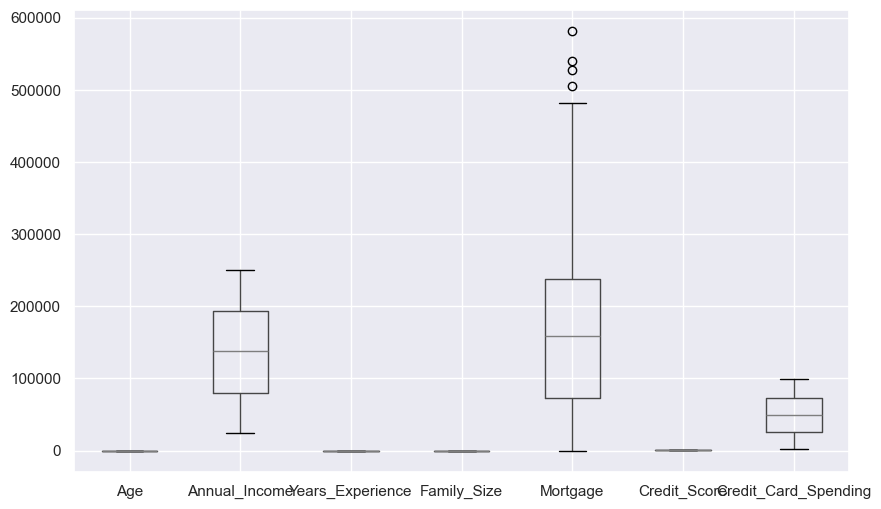

In [69]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

### Encoding

In [70]:
df.head()

,Age,Annual_Income,Years_Experience,Family_Size,Education,Mortgage,Credit_Score,Credit_Card_Spending,Online_Banking,Fixed_Deposit,City_Tier,Loan_Approved
0,59,171867,34,3,Postgraduate,6263,714,39194,Yes,Yes,Tier-1,Yes
1,22,84735,0,2,Graduate,406999,776,85104,Yes,No,Tier-2,No
2,48,27747,21,3,Graduate,147065,806,43606,Yes,Yes,Tier-3,Yes
3,29,179969,4,2,Postgraduate,192666,763,82077,Yes,Yes,Tier-2,Yes
4,24,196829,0,2,Postgraduate,238615,714,93387,Yes,Yes,Tier-1,Yes


In [71]:
oe=OrdinalEncoder()
for i in df.columns:
    if df[i].dtype==object and i != 'Loan_Approved':
        df[i]=oe.fit_transform(df[[i]])

In [72]:
df.head()

,Age,Annual_Income,Years_Experience,Family_Size,Education,Mortgage,Credit_Score,Credit_Card_Spending,Online_Banking,Fixed_Deposit,City_Tier,Loan_Approved
0,59,171867,34,3,1.0,6263,714,39194,1.0,1.0,0.0,Yes
1,22,84735,0,2,0.0,406999,776,85104,1.0,0.0,1.0,No
2,48,27747,21,3,0.0,147065,806,43606,1.0,1.0,2.0,Yes
3,29,179969,4,2,1.0,192666,763,82077,1.0,1.0,1.0,Yes
4,24,196829,0,2,1.0,238615,714,93387,1.0,1.0,0.0,Yes


### Define X and Y

In [73]:
x=df.iloc[:,:-1]
y=df['Loan_Approved']

### Spliting into train and test data

In [74]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

### Model Building

In [75]:
dt=DecisionTreeClassifier(criterion='gini')
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

### Check whether the model is underfitting or overfitting

In [76]:
print(f'Train Score= {dt.score(xtrain,ytrain)}')
print(f'Test score = {dt.score(xtest,ytest)}')

Train Score= 1.0
Test score = 0.81


### The model indicates overfitting we have to do hyperparameter tuning

### Create decision tree

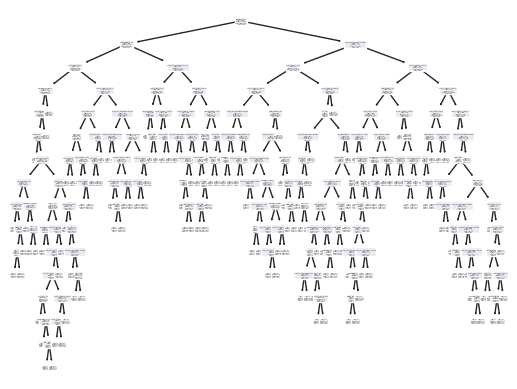

In [77]:
tree.plot_tree(dt,feature_names=x.columns, class_names=df['Loan_Approved'].unique())
plt.show()

### To find the depth of the trained tree.

In [78]:
dt.get_depth()

15

### The number of leaf nodes (terminal nodes) in your trained Decision Tree.

In [79]:
dt.get_n_leaves()

np.int64(154)

### Hyperparameter Tuning

#### 1) Pre-Pruning: Pre-pruning means stopping the Decision Tree from growing too much while the tree is being built.(Depth, min_sample_split)

##### max_depth controls how deep the tree can grow.
##### min_samples_split controls when a node can be split.

In [80]:
params={
    'max_depth':[3,5,8,9],
    'min_samples_split':[3,4,5,6]
}

#### Instead of manually training the 16 model Grid Search does it automatically and selects the best-performing model.

In [81]:
Grid=GridSearchCV(DecisionTreeClassifier(criterion='gini',random_state=42), params,verbose=1)

### Train the model

In [82]:
Grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 8, 9],
                         'min_samples_split': [3, 4, 5, 6]},
             verbose=1)

### find the best max_depth and min_sample_split

In [83]:
Grid.best_params_

{'max_depth': 5, 'min_samples_split': 3}

### Again train the model with perfect max_depth and min_samples_split numbers

In [84]:
Model= DecisionTreeClassifier(criterion='gini',max_depth=5, min_samples_split=3, random_state=42)
Model.fit(xtrain, ytrain)
Model.score(xtrain,ytrain), Model.score(xtest,ytest)

(0.9133333333333333, 0.8566666666666667)

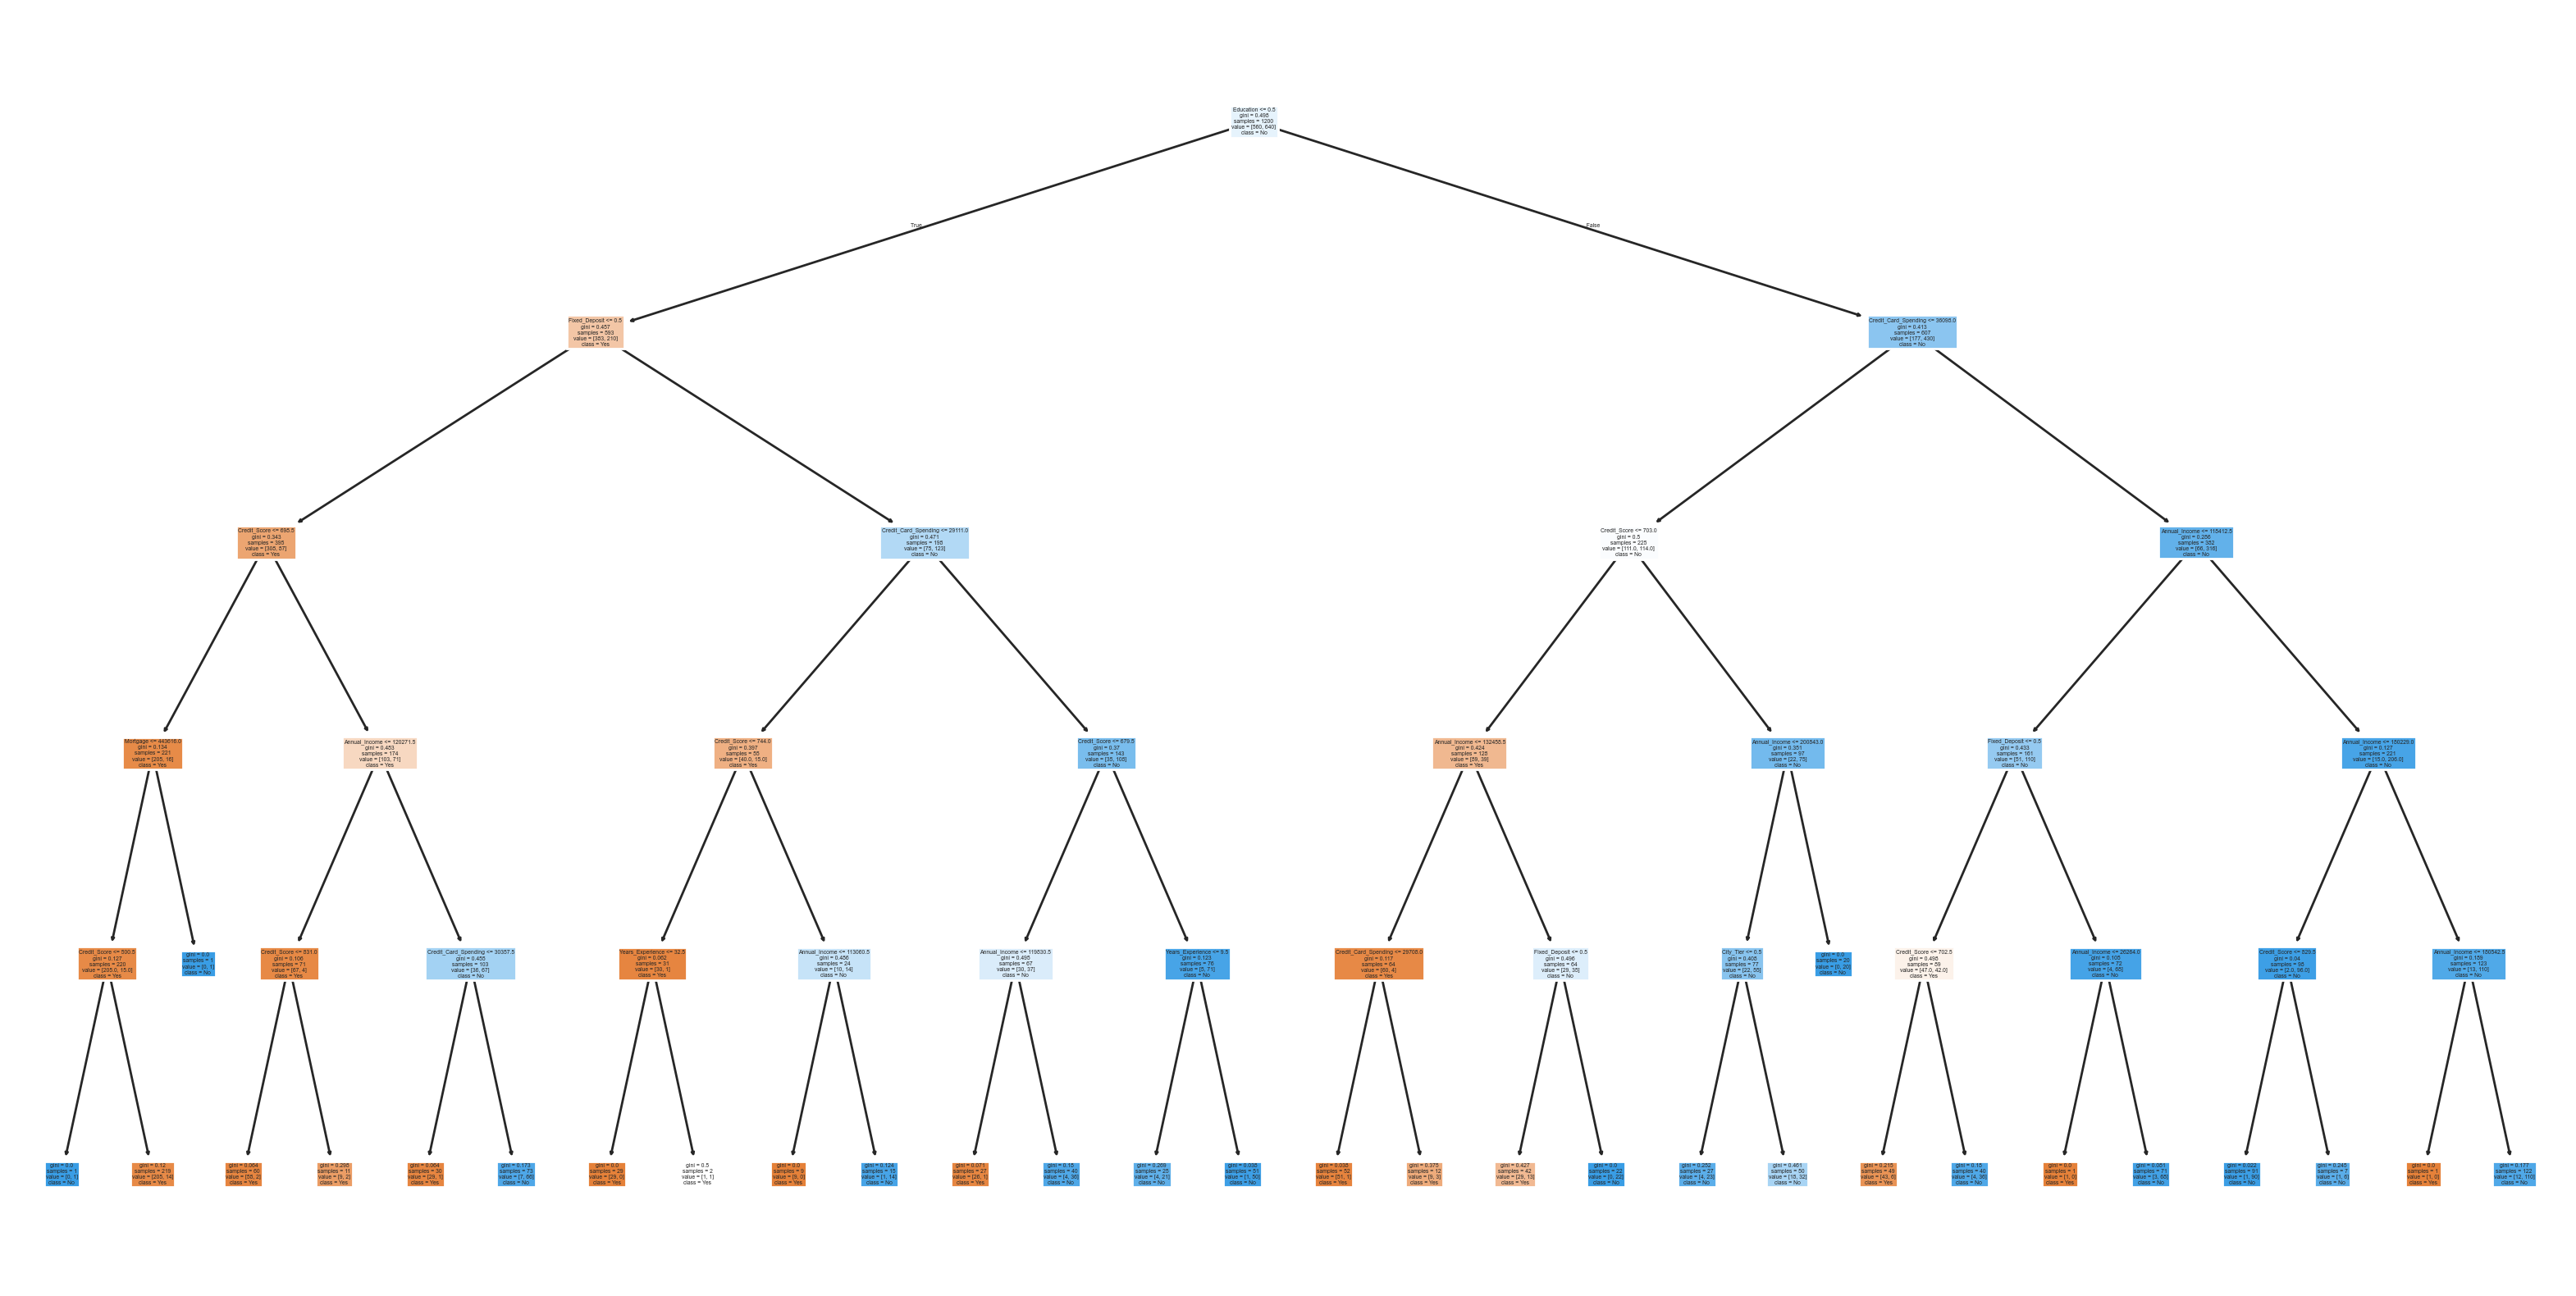

In [85]:
plt.figure(figsize=(20,10), dpi=200)
tree.plot_tree(Model,feature_names=x.columns, class_names=y.unique(),filled=True)
plt.show()

### Post Pruning With CCP

### Post-pruning means first allowing the Decision Tree to grow, and then removing unnecessary branches to reduce overfitting.

In [86]:
post_model=DecisionTreeClassifier(criterion='gini',random_state=42)
post_model.fit(xtrain,ytrain)

DecisionTreeClassifier(random_state=42)

In [87]:
post_model.get_depth()

15

In [88]:
alpha=post_model.cost_complexity_pruning_path(x,y)['ccp_alphas']
alpha

array([0.        , 0.00044083, 0.00058333, 0.00058824, 0.00061742,
       0.00062745, 0.00062745, 0.00063158, 0.00064103, 0.00064516,
       0.00064583, 0.00064583, 0.00064957, 0.00065   , 0.00065041,
       0.00065139, 0.00065359, 0.00065537, 0.00065672, 0.00066667,
       0.00066875, 0.00071367, 0.0008    , 0.0008    , 0.0008    ,
       0.00081333, 0.00083154, 0.00083333, 0.00084237, 0.00084848,
       0.00088886, 0.00088889, 0.00088889, 0.00088889, 0.00088889,
       0.00091011, 0.00091116, 0.00091585, 0.00093265, 0.00093344,
       0.00095463, 0.00096703, 0.001     , 0.001     , 0.00105353,
       0.00106667, 0.00106667, 0.00109253, 0.00109727, 0.00111111,
       0.00111111, 0.00111111, 0.00113949, 0.00114286, 0.00114469,
       0.0011742 , 0.00119738, 0.00119861, 0.00123887, 0.0012549 ,
       0.00127928, 0.00129293, 0.00133779, 0.00138889, 0.00138889,
       0.00145859, 0.0015184 , 0.00163533, 0.00171255, 0.00185759,
       0.00244957, 0.0054683 , 0.00801435, 0.00843086, 0.01070

In [89]:
len(alpha)

83

In [90]:
train=[]
test=[]
ccp=[]

for i in alpha:
    model=DecisionTreeClassifier(criterion='gini', ccp_alpha=i,random_state=42)
    model.fit(xtrain,ytrain)
    train.append(model.score(xtrain,ytrain))
    test.append(model.score(xtest,ytest))
    ccp.append(i)

### find maximum test accuracy

In [91]:
np.max(test)

np.float64(0.8666666666666667)

### Find index position of where the max value is present

In [92]:
np.argmax(test)

np.int64(70)

In [93]:
ccp[70]

np.float64(0.002449568834889938)

### Create Model creation with ccp_alpha value

In [94]:
final_model= DecisionTreeClassifier(criterion='gini',ccp_alpha=0.002449568834889938,random_state=42)
final_model.fit(xtrain, ytrain)
final_model.score(xtrain, ytrain), final_model.score(xtest, ytest)

(0.9141666666666667, 0.8666666666666667)

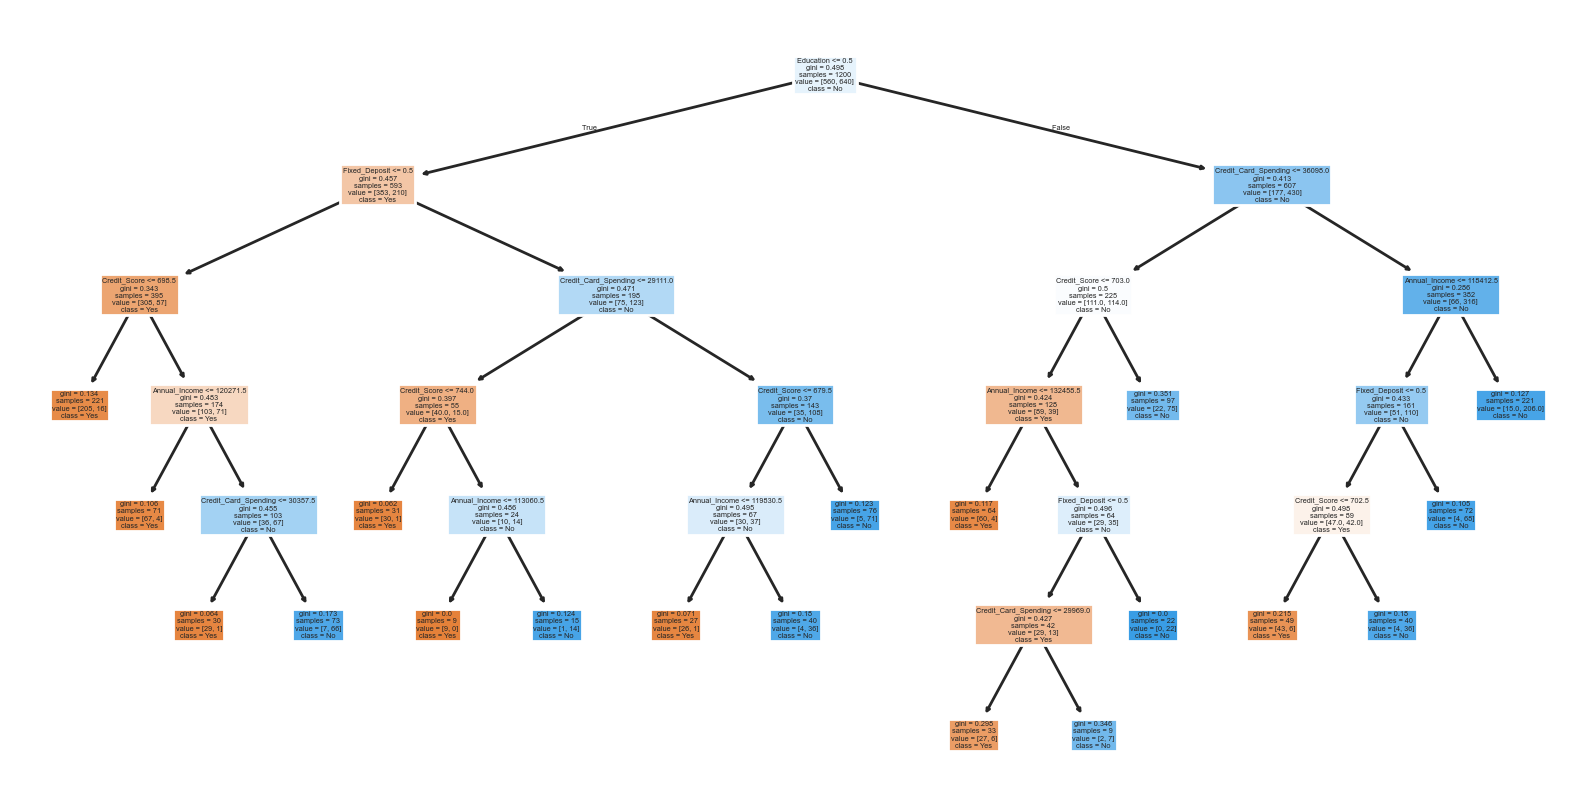

In [95]:
plt.figure(figsize=(10,5),dpi=200)
tree.plot_tree(final_model,feature_names=x.columns,class_names=df['Loan_Approved'].unique(),filled=True)
plt.show()

<p> Conclusion: The CART Decision Tree model was successfully developed to predict Loan Approval based on the available applicant and loan-related features. Initially, the model achieved a very high training accuracy compared with the test accuracy, indicating a possibility of overfitting.

To improve the model's generalization, both pre-pruning and post-pruning techniques were applied. In pre-pruning, max_depth and min_samples_split were tuned using GridSearchCV. The selected parameters were max_depth = 5 and min_samples_split = 3, which helped control the complexity of the tree.

Post-pruning was then performed using Cost Complexity Pruning (CCP). The ccp_alpha value was selected based on test-set performance, and the final pruned model was created using ccp_alpha = 0.002449568834889938.

Overall, the final CART model provides a more controlled and generalized decision-making model for loan approval. Pruning reduces unnecessary branches and helps minimize overfitting, making the model more suitable for practical loan approval prediction. </p>